# 모델3 : LightGBM
여러 개의 결정트리를 순차적으로 학습하며 이전 트리의 오류를 보완하는 앙상블 모델.
비선형 관계와 변수 간 상호작용을 효과적으로 학습.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report)

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
PROCESSED_DIR = "/content/drive/MyDrive/Matrix/Conference2026"

X_train = pd.read_csv(os.path.join(PROCESSED_DIR, "X_train.csv"))
X_test = pd.read_csv(os.path.join(PROCESSED_DIR, "X_test.csv"))
y_train = pd.read_csv(os.path.join(PROCESSED_DIR, "y_train.csv")).squeeze("columns")
y_test = pd.read_csv(os.path.join(PROCESSED_DIR, "y_test.csv")).squeeze("columns")

## 모델링

In [16]:
## 초기 모델

initial_model = LGBMClassifier(n_estimators = 300, learning_rate = 0.05, random_state = 42)
initial_model.fit(X_train, y_train)

y_pred_initial = initial_model.predict(X_test)
y_prob_initial = initial_model.predict_proba(X_test)[:, 1]

print(f"Recall   : {recall_score(y_test, y_pred_initial):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_initial):.4f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 43667, number of negative: 54586
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023636 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 182
[LightGBM] [Info] Number of data points in the train set: 98253, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.444434 -> initscore=-0.223185
[LightGBM] [Info] Start training from score -0.223185
Recall   : 0.7827
F1 Score : 0.7226
PR-AUC   : 0.7463


In [14]:
## 하이퍼파라미터 튜닝

param_grid = {
    "n_estimators" : [100, 200, 300, 400],
    "learning_rate": [0.05, 0.07, 0.1],
    "num_leaves": [15, 31, 63]
}

grid = GridSearchCV(
    estimator = LGBMClassifier(random_state = 42),
    param_grid = param_grid,
    scoring = "f1",
    cv = 5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print(f"Best CV F1-score: {grid.best_score_:.4f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 43667, number of negative: 54586
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015328 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 182
[LightGBM] [Info] Number of data points in the train set: 98253, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.444434 -> initscore=-0.223185
[LightGBM] [Info] Start training from score -0.223185
Best Params: {'learning_rate': 0.05, 'n_estimators': 100, 'num_leaves': 31}
Best CV F1-score: 0.7042


In [17]:
 # 테스트 데이터에서는 초기 모델이 더 우수한 성능을 보여 최종 모델로 초기 모델을 채택.

lgbm = initial_model

y_pred = lgbm.predict(X_test)
y_prob = lgbm.predict_proba(X_test)[:, 1]

# 교차검증
교차검증을 통해 훈련 데이터를 여러 번 다른 방식으로 나누어 반복 학습, 평가함으로써 모델 성능이 특정 데이터 분할에만 의존하지 않는지 확인함.
 또한 평균 성능과 표준편차를 통해 모델의 안정성과 일반화 가능성을 평가함.

In [8]:
# 5-Fold 교차검증
cv = StratifiedKFold(
    n_splits = 5,
    shuffle = True,
    random_state = 42
)

# 현재 모델 그대로 사용
cv_model = LGBMClassifier(
    random_state = 42,
    n_estimators = 300,
    learning_rate = 0.05
)

for scoring in ["accuracy", "f1", "roc_auc"]:
    scores = cross_val_score(
        cv_model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    print(f"{scoring:>10}: {scores.mean():.4f} ± {scores.std():.4f}")

  accuracy: 0.7288 ± 0.0034
        f1: 0.7175 ± 0.0035
   roc_auc: 0.8091 ± 0.0027




표준편차가 낮아 5번의 교차검증에서 각 성능이 비슷함을 알 수 있고, 안정적 모델임을 확인

# 최종 모델 성능 평가

In [18]:
accuracy = accuracy_score(y_test, y_pred) # 전체 예측 중 맞힌 비율
precision = precision_score(y_test, y_pred) # 입양될 거라고 예측한 동물 중 실제 입양된 비율
recall = recall_score(y_test, y_pred) # 실제 입양된 동물 중 예측 성공한 비율
f1 = f1_score(y_test, y_pred) # Precision과 Recall의 균형
roc_auc = roc_auc_score(y_test, y_prob) # 모델이 두 클래스를 얼마나 잘 구분하는지
pr_auc = average_precision_score(y_test, y_prob) # 모델이 Precision과 Recall을 동시에 얼마나 잘 유지하는지

print("=" * 50)
print("LightGBM Performance")
print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

LightGBM Performance
Accuracy : 0.7320
Precision: 0.6712
Recall   : 0.7827
F1 Score : 0.7226
ROC-AUC  : 0.8130
PR-AUC   : 0.7463

Confusion Matrix
[[9419 4208]
 [2385 8589]]

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.69      0.74     13627
           1       0.67      0.78      0.72     10974

    accuracy                           0.73     24601
   macro avg       0.73      0.74      0.73     24601
weighted avg       0.74      0.73      0.73     24601



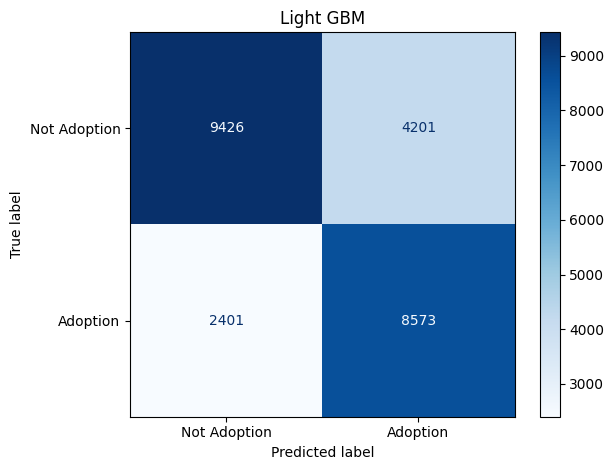

In [9]:
# 혼동행렬

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["Not Adoption", "Adoption"])
disp.plot(cmap="Blues")
plt.title("Light GBM")
plt.tight_layout()
plt.show()

# 모델의 예측 결과 해석

lgbm은 여러 의사결정나무를 조합하는 모델, 블락박스 모델로, 즉 로지스틱 회귀처럼 계수같은 걸로 어떤 변수가 예측에 얼마나 영향을 미쳤는지 해석하기 어려움. -> SHAP을 활용하여 변수별 예측 기여도와 영향 방향을 분석하고, 이를 바탕으로 모델의 예측을 해석.

-> 입양률 향상을 위한 보호소 운영 전략 도출에 필요한 주요 영향 요인 파악

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


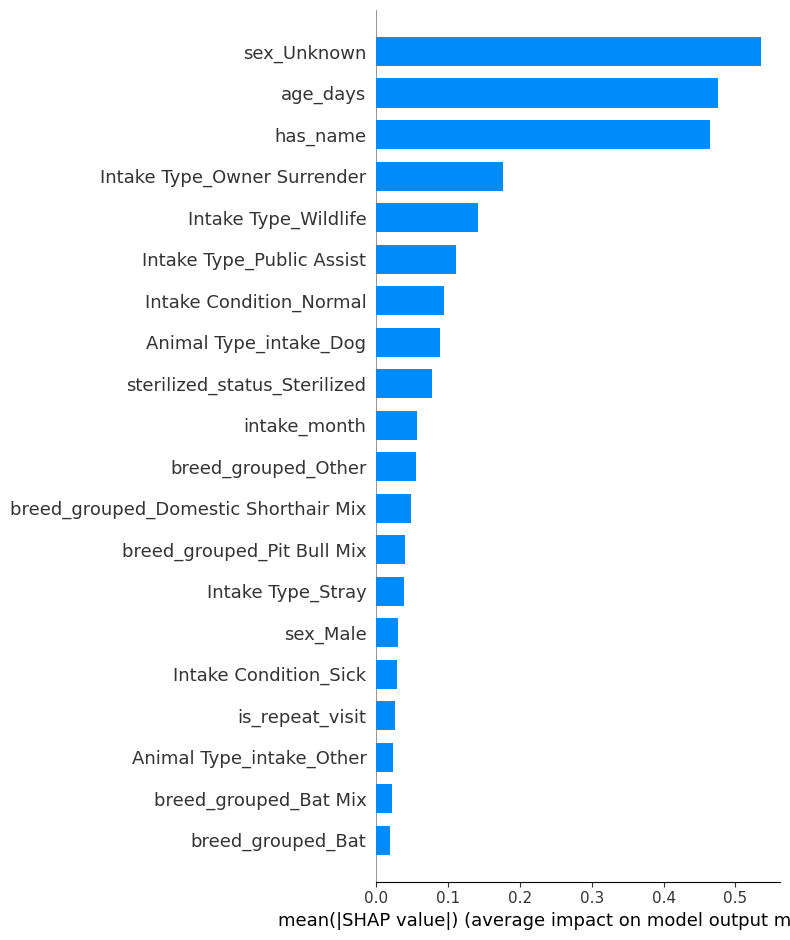

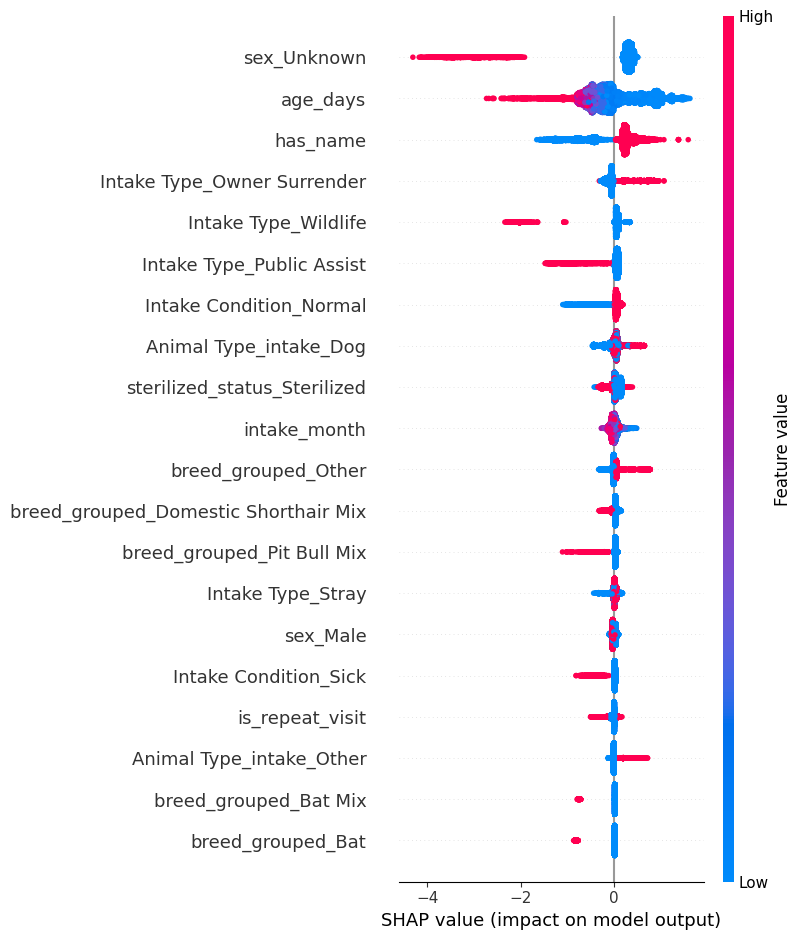

In [13]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(
    shap_values,
    X_test,
    plot_type = "bar"
)

## 실제 예측에 기여한 변수 중요도
shap.summary_plot(
    shap_values,
    X_test
)

## 변수 영향 방향
# SHAP value > 0 : 입양으로 예측할 가능성을 높인 변수
# SHAP value < 0 : 미입양으로 예측할 가능성을 높인 변수
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

In [ ]:
joblib.dump(lgbm, "/content/drive/MyDrive/Matrix/Conference2026/lgbm_model.pkl")
print("\n모델 저장 완료: lgbm_model.pkl")